In [3]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import  DataLoader
from torchvision import transforms
import os
from PIL import Image
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

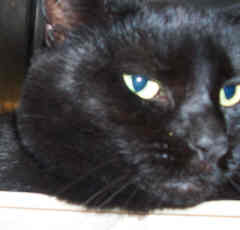

In [9]:
with Image.open("../CNN_Image_Classification/CATS_DOGS/test/CAT/9374.jpg") as img:
    display(img)

### Create a list of file name

In [16]:
path = "../CNN_Image_Classification/CATS_DOGS"

img_names= []

for folder, subfolders ,filenames in os.walk(path):
    for img in filenames:
        img_names.append(folder+"/"+img)

print(img_names)

['../CNN_Image_Classification/CATS_DOGS/.DS_Store', '../CNN_Image_Classification/CATS_DOGS\\test/.DS_Store', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10000.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10001.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10002.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10003.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10004.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10005.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10006.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10007.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10008.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10009.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10010.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10011.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10012.jpg', '../CNN_Image_Classification/CATS_DOGS\\test\\CAT/10013.jpg', '../CNN_Image_Classific

In [17]:
### Create a DF of image sizes (Width, height)

img_sizes=[]
rejected = []

for i in img_names:
    try :
        with Image.open(i) as i:
            img_sizes.append(i.size)
    except:
        rejected.append(i)

print(f"Images: {len(img_sizes)}")
print(f"Rejected: {len(rejected)}")

Images: 24994
Rejected: 3


In [18]:
df= pd.DataFrame(img_sizes)

In [21]:
df.head()
# 0 = width of image
# 1 = Height of image

,0,1
0,431,360
1,500,375
2,500,471
3,500,375
4,320,240


In [24]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24994 entries, 0 to 24993
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       24994 non-null  int64
 1   1       24994 non-null  int64
dtypes: int64(2)
memory usage: 390.7 KB


In [23]:
df.describe()

,0,1
count,24994.000000,24994.000000
mean,404.493518,361.037129
std,108.941802,96.936811
min,42.000000,33.000000
25%,323.000000,302.000000
50%,448.000000,375.000000
75%,500.000000,421.000000
max,500.000000,500.000000


### Tranformations

(375, 500)


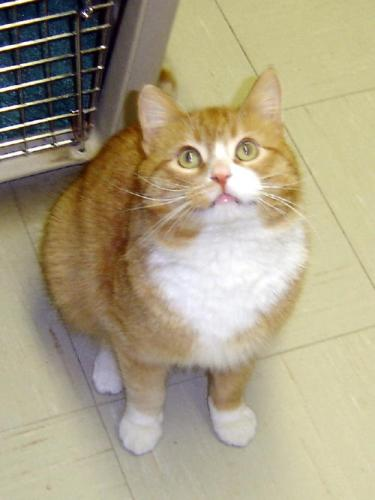

In [30]:
cat=Image.open("../CNN_Image_Classification/CATS_DOGS\\train\\CAT/5468.jpg")
print(cat.size)
display(cat)

In [33]:
r,g,b= cat.getpixel((0,0))
print(r,g,b)

16 31 100


### transforms to tensors


In [38]:
transform = transforms.Compose([
    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)

torch.Size([3, 500, 375])


In [39]:
im

tensor([[[0.0627, 0.0863, 0.1020,  ..., 0.7647, 0.7647, 0.7647],
         [0.1020, 0.1255, 0.1412,  ..., 0.7686, 0.7686, 0.7686],
         [0.1412, 0.1490, 0.1608,  ..., 0.7725, 0.7725, 0.7725],
         ...,
         [0.7922, 0.7882, 0.7804,  ..., 0.8431, 0.8431, 0.8471],
         [0.7922, 0.7882, 0.7804,  ..., 0.8431, 0.8471, 0.8471],
         [0.7961, 0.7922, 0.7843,  ..., 0.8471, 0.8471, 0.8471]],

        [[0.1216, 0.1451, 0.1529,  ..., 0.7412, 0.7412, 0.7412],
         [0.1373, 0.1608, 0.1804,  ..., 0.7451, 0.7451, 0.7451],
         [0.1451, 0.1529, 0.1647,  ..., 0.7490, 0.7490, 0.7490],
         ...,
         [0.7686, 0.7647, 0.7569,  ..., 0.8275, 0.8275, 0.8314],
         [0.7686, 0.7647, 0.7569,  ..., 0.8275, 0.8314, 0.8314],
         [0.7725, 0.7686, 0.7608,  ..., 0.8314, 0.8314, 0.8314]],

        [[0.3922, 0.4157, 0.4196,  ..., 0.5373, 0.5373, 0.5373],
         [0.3922, 0.4157, 0.4235,  ..., 0.5412, 0.5412, 0.5412],
         [0.3686, 0.3725, 0.3765,  ..., 0.5451, 0.5451, 0.

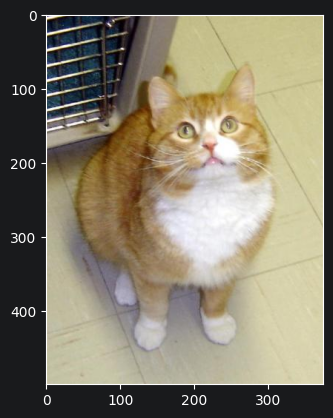

In [43]:
plt.imshow(np.transpose(im.numpy(),(1,2,0)))
plt.show()

* pytorch format --->> (C,H,W)


torch.Size([3, 224, 224])


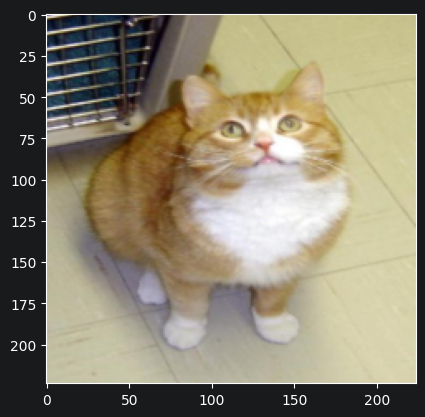

In [53]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

### Transform.CenterCrop

torch.Size([3, 124, 124])


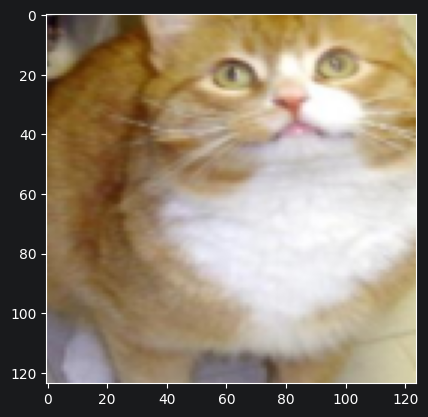

In [55]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.CenterCrop((124)),

    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

 ### transforms.HorizontalFilp

torch.Size([3, 500, 375])


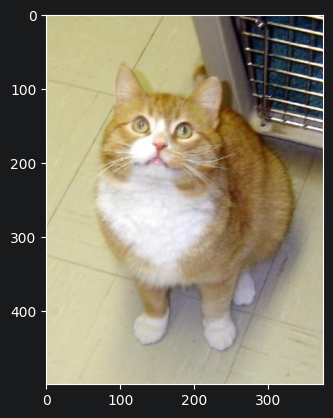

In [58]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),

    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

### Transform.RandomRotation


torch.Size([3, 500, 375])


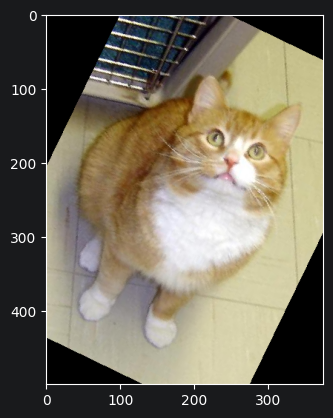

In [59]:
transform = transforms.Compose([
    transforms.RandomRotation(30),

    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

torch.Size([3, 500, 375])


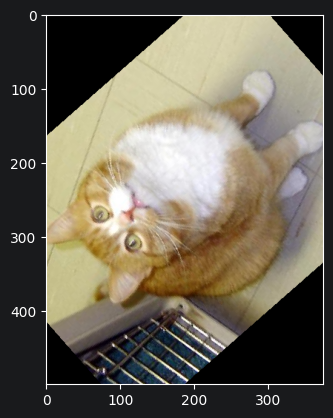

In [64]:
transform = transforms.Compose([
    transforms.RandomRotation((1,359)),

    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

### putting all tranformation together


torch.Size([3, 224, 224])


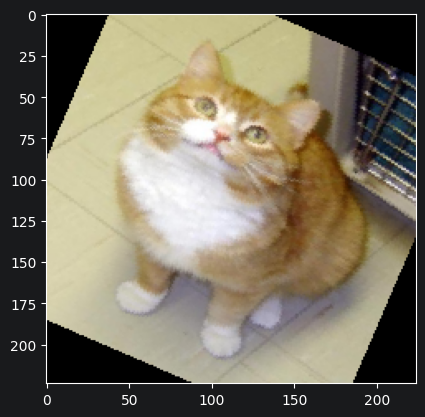

In [66]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(p=0.5),


    transforms.ToTensor()
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

### normalization

* mean =[0.485,0.456,.406]
* std= [0.229,.334,.225]
*

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


torch.Size([3, 500, 375])


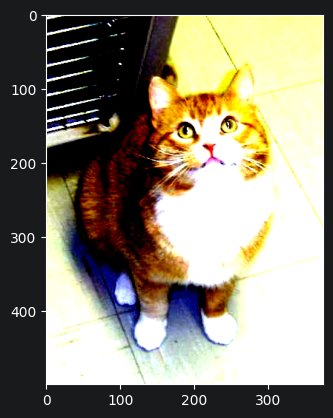

In [68]:
transform = transforms.Compose([



    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

im=transform(cat)
print(im.shape)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))
plt.show()

In [70]:
im[:,0,0]

tensor([-1.8439, -1.4930, -0.0615])

### De Normalazation the images

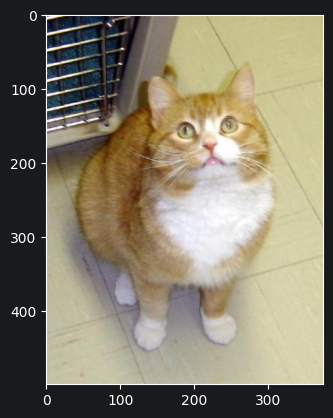

In [74]:
inv_normazation = transforms.Normalize(mean=[-0.485/0.229, -0.456/.224,-0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])
inv=inv_normazation(im)
plt.imshow(np.transpose(inv.numpy(), (1, 2, 0)))
plt.show()